# Cont–Kukanov–Stoikov: order flow imbalance

This notebook reproduces the **Level I OFI** definition from [Cont, Kukanov & Stoikov, *The Price Impact of Order Book Events*](https://arxiv.org/pdf/1011.6402), §2.1–2.3, on the Binance BTC perpetual snapshots in our capture. The paper studies the **contemporaneous** relation between OFI and mid-price changes. A separate next-second check below is our exploratory predictive extension, not a claim made by the paper.

We use the existing chronological train/validation/test boundaries. **Test rows are not loaded.** This notebook makes no orders, execution or PnL assumptions. Prices and sizes become `float64` only in this offline analysis; the canonical capture stays exact.

In [1]:
from pathlib import Path
import sys
import polars as pl
import matplotlib.pyplot as plt

PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "backend").is_dir())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from experiments.simulator.splits import chronological_splits

DATASET = PROJECT_ROOT / "experiments/data/parquet/6b556515-5156-4181-8a6f-7403fa9078fe"
VENUE = "binance"
BAR_NS = 1_000_000_000  # one second on the local receive clock
train, validation, test = chronological_splits(DATASET)
print(train, validation, test)
assert DATASET.is_dir()

Matplotlib is building the font cache; this may take a moment.


Split(name='train', sequence_start=1, sequence_end=2403822) Split(name='validation', sequence_start=2403822, sequence_end=3514231) Split(name='test', sequence_start=3514231, sequence_end=None)


## Reconstruct the best quote from the recorded L2 snapshots

`best_bid_offers` has zero rows in this capture. We take position 0 on each side of each accepted `order_book_events` snapshot, joined by Capture Sequence. Sequence is the canonical observation order; local receive time is used only to form time bars. Binance has no `order_book` unavailable transition in this capture. We assert complete, uncrossed quotes before computing OFI.

In [2]:
def table_files(kind: str) -> list[str]:
    files = sorted(str(p) for p in DATASET.glob(
        f"**/event_type={kind}/venue={VENUE}/**/*.parquet"
    ))
    if not files:
        raise FileNotFoundError(f"missing {kind} for {VENUE}")
    return files

availability_files = table_files("availability_events")
book_unavailable = (
    pl.scan_parquet(availability_files, hive_partitioning=True)
    .filter((pl.col("stream") == "order_book") & (pl.col("transition") == "unavailable"))
    .select(pl.len()).collect().item()
)
assert book_unavailable == 0, "OFI needs reset at book unavailability"

book_events = (
    pl.scan_parquet(table_files("order_book_events"), hive_partitioning=True)
    .filter(pl.col("capture_sequence") < test.sequence_start)
    .select("capture_sequence", "local_receive_time")
)
levels = (
    pl.scan_parquet(table_files("order_book_levels"), hive_partitioning=True)
    .filter((pl.col("position") == 0) & (pl.col("capture_sequence") < test.sequence_start))
    .select("capture_sequence", "side", "price", "quantity")
)
bid = levels.filter(pl.col("side") == "bid").select(
    "capture_sequence", pl.col("price").cast(pl.Float64).alias("bid_price"),
    pl.col("quantity").cast(pl.Float64).alias("bid_qty"),
)
ask = levels.filter(pl.col("side") == "ask").select(
    "capture_sequence", pl.col("price").cast(pl.Float64).alias("ask_price"),
    pl.col("quantity").cast(pl.Float64).alias("ask_qty"),
)
quotes = (
    book_events.join(bid, on="capture_sequence", how="left", validate="1:1")
    .join(ask, on="capture_sequence", how="left", validate="1:1")
    .with_columns(
        pl.when(pl.col("capture_sequence") < validation.sequence_start)
        .then(pl.lit("train")).otherwise(pl.lit("validation")).alias("split")
    )
    .sort("capture_sequence")
    .collect()
)
assert quotes.select(pl.any_horizontal(pl.all().is_null()).any()).item() is False
assert quotes.filter((pl.col("bid_price") > pl.col("ask_price")) | (pl.col("bid_qty") <= 0) | (pl.col("ask_qty") <= 0)).is_empty()
print(quotes.group_by("split").len().sort("split"))

shape: (2, 2)
┌────────────┬────────┐
│ split      ┆ len    │
│ ---        ┆ ---    │
│ str        ┆ u32    │
╞════════════╪════════╡
│ train      ┆ 439364 │
│ validation ┆ 158970 │
└────────────┴────────┘


In [6]:
quotes.head()

capture_sequence,local_receive_time,bid_price,bid_qty,ask_price,ask_qty,split
u64,u64,f64,f64,f64,f64,str
4,1085388728,84887.5,7.566,84887.6,1.702,"""train"""
7,1187538285,84887.5,7.329,84887.6,1.7,"""train"""
9,1289955213,84887.5,7.332,84887.6,1.701,"""train"""
14,1391399413,84887.5,7.334,84887.6,1.702,"""train"""
17,1493345267,84887.5,7.34,84887.6,1.685,"""train"""


## Event OFI

For consecutive quotes within one split, the paper defines

$$e_n=\mathbf{1}_{b_n\ge b_{n-1}}q^B_n-\mathbf{1}_{b_n\le b_{n-1}}q^B_{n-1}-\mathbf{1}_{a_n\le a_{n-1}}q^A_n+\mathbf{1}_{a_n\ge a_{n-1}}q^A_{n-1}.$$

The equality cases make an unchanged price contribute the **change in queue size**. We reset the previous quote at the train/validation boundary. Full snapshots reveal net quote changes between observations; they cannot identify each underlying add, cancel or market order.

In [8]:
def add_event_ofi(frame: pl.DataFrame) -> pl.DataFrame:
    frame = frame.sort("split", "capture_sequence").with_columns(
        pl.col("bid_price").shift(1).over("split").alias("prev_bid_price"),
        pl.col("bid_qty").shift(1).over("split").alias("prev_bid_qty"),
        pl.col("ask_price").shift(1).over("split").alias("prev_ask_price"),
        pl.col("ask_qty").shift(1).over("split").alias("prev_ask_qty"),
    )
    return frame.with_columns(
        pl.when(pl.col("prev_bid_price").is_null()).then(None).otherwise(
            pl.when(pl.col("bid_price") >= pl.col("prev_bid_price")).then(pl.col("bid_qty")).otherwise(0)
            - pl.when(pl.col("bid_price") <= pl.col("prev_bid_price")).then(pl.col("prev_bid_qty")).otherwise(0)
            - pl.when(pl.col("ask_price") <= pl.col("prev_ask_price")).then(pl.col("ask_qty")).otherwise(0)
            + pl.when(pl.col("ask_price") >= pl.col("prev_ask_price")).then(pl.col("prev_ask_qty")).otherwise(0)
        ).alias("ofi_event"),
        ((pl.col("bid_price") + pl.col("ask_price")) / 2).alias("mid_price"),
    )

fixture = pl.DataFrame({
    "split": ["train"] * 5,
    "capture_sequence": [1, 2, 3, 4, 5],
    "bid_price": [100., 100., 99., 99., 99.],
    "bid_qty": [1., 2., 3., 3., 3.],
    "ask_price": [101., 101., 101., 100., 101.],
    "ask_qty": [1., 1., 1., 2., 1.],
})
assert add_event_ofi(fixture)["ofi_event"].to_list() == [None, 1., -2., -2., 2.]

observations = add_event_ofi(quotes)
assert observations.filter(pl.col("ofi_event").is_null()).height == 2  # first quote in each split
print(observations.select("split", "capture_sequence", "ofi_event", "mid_price").head())

shape: (5, 4)
┌───────┬──────────────────┬───────────┬───────────┐
│ split ┆ capture_sequence ┆ ofi_event ┆ mid_price │
│ ---   ┆ ---              ┆ ---       ┆ ---       │
│ str   ┆ u64              ┆ f64       ┆ f64       │
╞═══════╪══════════════════╪═══════════╪═══════════╡
│ train ┆ 4                ┆ null      ┆ 84887.55  │
│ train ┆ 7                ┆ -0.235    ┆ 84887.55  │
│ train ┆ 9                ┆ 0.002     ┆ 84887.55  │
│ train ┆ 14               ┆ 0.001     ┆ 84887.55  │
│ train ┆ 17               ┆ 0.023     ┆ 84887.55  │
└───────┴──────────────────┴───────────┴───────────┘


In [9]:
observations.head()

capture_sequence,local_receive_time,bid_price,bid_qty,ask_price,ask_qty,split,prev_bid_price,prev_bid_qty,prev_ask_price,prev_ask_qty,ofi_event,mid_price
u64,u64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64
4,1085388728,84887.5,7.566,84887.6,1.702,"""train""",null,null,null,null,null,84887.55
7,1187538285,84887.5,7.329,84887.6,1.7,"""train""",84887.5,7.566,84887.6,1.702,-0.235,84887.55
9,1289955213,84887.5,7.332,84887.6,1.701,"""train""",84887.5,7.329,84887.6,1.7,0.002,84887.55
14,1391399413,84887.5,7.334,84887.6,1.702,"""train""",84887.5,7.332,84887.6,1.701,0.001,84887.55
17,1493345267,84887.5,7.34,84887.6,1.685,"""train""",84887.5,7.334,84887.6,1.702,0.023,84887.55


## One-second bars

Sum event contributions in each observed second. Compare the last mid quote of adjacent seconds only; a missing second does not silently forward-fill a price. The paper uses price change in ticks. Here the response is in USD because a single canonical tick size is not established for this research adapter.

In [10]:
bars = (
    observations.drop_nulls("ofi_event")
    .with_columns((pl.col("local_receive_time") // BAR_NS).alias("bar"))
    .group_by("split", "bar")
    .agg(pl.sum("ofi_event").alias("ofi"), pl.last("mid_price").alias("mid"), pl.len().alias("book_events"))
    .sort("split", "bar")
    .with_columns(
        pl.col("bar").shift(1).over("split").alias("prev_bar"),
        pl.col("mid").shift(1).over("split").alias("prev_mid"),
        pl.col("bar").shift(-1).over("split").alias("next_bar"),
        pl.col("mid").shift(-1).over("split").alias("next_mid"),
    )
    .with_columns(
        pl.when(pl.col("bar") - pl.col("prev_bar") == 1)
        .then(pl.col("mid") - pl.col("prev_mid")).alias("same_bar_change_usd"),
        pl.when(pl.col("next_bar") - pl.col("bar") == 1)
        .then(pl.col("next_mid") - pl.col("mid")).alias("next_bar_change_usd"),
    )
)
print(bars.group_by("split").agg(
    pl.len().alias("observed_bars"),
    pl.col("same_bar_change_usd").is_not_null().sum().alias("adjacent_same_bar"),
    pl.col("next_bar_change_usd").is_not_null().sum().alias("adjacent_next_bar"),
).sort("split"))

shape: (2, 4)
┌────────────┬───────────────┬───────────────────┬───────────────────┐
│ split      ┆ observed_bars ┆ adjacent_same_bar ┆ adjacent_next_bar │
│ ---        ┆ ---           ┆ ---               ┆ ---               │
│ str        ┆ u32           ┆ u32               ┆ u32               │
╞════════════╪═══════════════╪═══════════════════╪═══════════════════╡
│ train      ┆ 49698         ┆ 49678             ┆ 49678             │
│ validation ┆ 16588         ┆ 16587             ┆ 16587             │
└────────────┴───────────────┴───────────────────┴───────────────────┘


In [14]:
bars.head()

split,bar,ofi,mid,book_events,prev_bar,prev_mid,next_bar,next_mid,same_bar_change_usd,next_bar_change_usd
str,u64,f64,f64,u32,u64,f64,u64,f64,f64,f64
"""train""",1,-0.245,84887.55,8,null,null,2,84887.55,null,0.0
"""train""",2,-0.624,84887.55,9,1,84887.55,3,84894.55,0.0,7.0
"""train""",3,9.398,84894.55,10,2,84887.55,4,84894.55,7.0,0.0
"""train""",4,-0.897,84894.55,9,3,84894.55,5,84894.55,0.0,0.0
"""train""",5,-0.54,84894.55,8,4,84894.55,6,84894.55,0.0,0.0


## Train once; evaluate on validation

The first fit is the paper's contemporaneous price-impact relation, $\Delta P_t=\alpha+\beta\,OFI_t+\epsilon_t$. Its validation result describes co-movement and is **not tradable prediction**. The second fit uses the same current OFI to forecast the next adjacent second. It is a separate exploratory signal check; we report out-of-sample $R^2$ against the validation mean and directional accuracy on non-zero moves. No tuning uses test.

In [17]:
def fit_line(frame: pl.DataFrame, target: str) -> tuple[float, float]:
    data = frame.drop_nulls(["ofi", target])
    stats = data.select(
        pl.col("ofi").mean().alias("mx"), pl.col(target).mean().alias("my"),
        (pl.col("ofi") * pl.col(target)).mean().alias("mxy"),
        (pl.col("ofi") * pl.col("ofi")).mean().alias("mxx"),
    ).row(0, named=True)
    variance = stats["mxx"] - stats["mx"] ** 2
    if data.height < 2 or variance <= 0:
        raise ValueError("OFI has insufficient variation")
    beta = (stats["mxy"] - stats["mx"] * stats["my"]) / variance
    return stats["my"] - beta * stats["mx"], beta


def score_line(frame: pl.DataFrame, target: str, model: tuple[float, float]) -> dict:
    data = frame.drop_nulls(["ofi", target])
    alpha, beta = model
    actual = data[target]
    predicted = data["ofi"] * beta + alpha
    mse = ((actual - predicted) ** 2).mean()
    baseline_mse = ((actual - actual.mean()) ** 2).mean()
    moving = actual != 0
    actual_up = actual.filter(moving) > 0
    direction = ((predicted.filter(moving) > 0) == actual_up).mean()
    up_rate = actual_up.mean()
    return {"bars": data.height, "mse_usd2": mse,
            "r2_vs_validation_mean": 1 - mse / baseline_mse,
            "direction_accuracy_nonzero": direction,
            "majority_direction_baseline": max(up_rate, 1 - up_rate),
            "nonzero_moves": moving.sum(),
            "nonzero_fraction": moving.mean()}

train_bars = bars.filter(pl.col("split") == "train")
validation_bars = bars.filter(pl.col("split") == "validation")
for target in ("same_bar_change_usd", "next_bar_change_usd"):
    model = fit_line(train_bars, target)
    print(target, "train alpha/beta:", model)
    print("validation:", score_line(validation_bars, target, model))

same_bar_change_usd train alpha/beta: (-0.01428797984535019, 0.23519943267718108)
validation: {'bars': 16587, 'mse_usd2': 16.107668123054502, 'r2_vs_validation_mean': 0.5046148742757877, 'direction_accuracy_nonzero': 0.9595498287391943, 'majority_direction_baseline': 0.5198173218072093, 'nonzero_moves': 6131, 'nonzero_fraction': 0.36962681618134685}
next_bar_change_usd train alpha/beta: (-0.009964909255357403, 0.047189791837497795)
validation: {'bars': 16587, 'mse_usd2': 31.561899075415482, 'r2_vs_validation_mean': 0.029325956921648078, 'direction_accuracy_nonzero': 0.7008644593051705, 'majority_direction_baseline': 0.5198173218072093, 'nonzero_moves': 6131, 'nonzero_fraction': 0.36962681618134685}


## Candidate directional signal (research only)

Freeze the next-second line fitted on train. Its sign gives a `long` or `short` **research signal** for the next adjacent second. There is no confidence threshold, order placement, inventory handling or cost model here; this is not a deployable strategy. The validation direction score above is conditioned on non-zero moves, so compare it with the majority-direction baseline and the non-zero fraction.

In [19]:
alpha, beta = fit_line(train_bars, "next_bar_change_usd")

validation_signals = (
    validation_bars
    .select("bar", "ofi")
    .with_columns(
        (alpha + beta * pl.col("ofi")).alias("prediction")
    )
    .with_columns(
        pl.when(pl.col("prediction") > 0)
        .then(pl.lit("long"))
        .otherwise(pl.lit("short"))
        .alias("direction")
    )
)

In [20]:
outcomes = validation_bars.select("bar", "next_bar_change_usd")

evaluation = validation_signals.join(outcomes, on="bar", how="left")
scored = evaluation.drop_nulls("next_bar_change_usd")

In [23]:
outcomes.head()

bar,next_bar_change_usd
u64,f64
49763,0.0
49764,-8.4
49765,-0.6
49766,0.0
49767,0.0


## Latency sensitivity of the validation signal

The signal uses only current-bar OFI and becomes available when that one-second bar closes. For each added delay, find the first Binance quote received locally after the delayed signal time. Compare its mid-price with the **same** next-bar closing mid-price at every delay. Keep the train-fitted coefficients fixed and do not read test.

This is a retrospective measure of how much mid-price movement remains after waiting. Local receive time is not exchange execution time, so these quotes are **not simulated fills**. Report coverage and the fraction of bars with nonzero remaining movement alongside directional accuracy; otherwise conditioning only on moving bars can hide the loss of opportunities.

In [ ]:
# The preceding signal cell must run first: no future outcome is allowed in this table.
assert validation_signals.height == validation_bars.height

quote_mid = (
    quotes.filter(pl.col("split") == "validation")
    .select(
        pl.col("local_receive_time").alias("quote_ns"),
        ((pl.col("bid_price") + pl.col("ask_price")) / 2).alias("entry_mid"),
    )
    .sort("quote_ns")
)
next_bar_labels = (
    validation_bars
    .filter(pl.col("next_bar") == pl.col("bar") + 1)
    .select("bar", "next_mid")
)


def score_delay(delay_ms: int) -> dict:
    # OFI for bar t is complete no earlier than the beginning of bar t+1.
    arrivals = (
        validation_signals.select("bar", "prediction")
        .with_columns(
            ((pl.col("bar") + 1) * BAR_NS + delay_ms * 1_000_000)
            .alias("arrival_ns")
        )
        .sort("arrival_ns")
    )
    observed = (
        arrivals.join_asof(
            quote_mid,
            left_on="arrival_ns",
            right_on="quote_ns",
            strategy="forward",
        )
        .join(next_bar_labels, on="bar", how="inner")
        .filter(
            pl.col("quote_ns").is_not_null()
            & (pl.col("quote_ns") < (pl.col("bar") + 2) * BAR_NS)
        )
        .with_columns(
            (pl.col("next_mid") - pl.col("entry_mid")).alias("remaining_move")
        )
    )
    moving = observed.filter(pl.col("remaining_move") != 0)
    hits = moving.select(
        ((pl.col("prediction") > 0) == (pl.col("remaining_move") > 0)).sum()
    ).item() if moving.height else 0
    return {
        "delay_ms": delay_ms,
        "coverage": observed.height / next_bar_labels.height,
        "move_fraction": moving.height / observed.height if observed.height else None,
        "accuracy_when_moving": hits / moving.height if moving.height else None,
        # Fixed denominator makes the delay scenarios directly comparable.
        "hit_fraction_all": hits / next_bar_labels.height,
    }


latency_results = pl.DataFrame([score_delay(ms) for ms in (0, 50, 100, 250, 500)])
print(latency_results)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    latency_results["delay_ms"], latency_results["hit_fraction_all"],
    marker="o", label="correct direction and nonzero move / all eligible bars",
)
ax.plot(
    latency_results["delay_ms"], latency_results["move_fraction"],
    marker="o", label="bars with remaining movement / observed bars",
)
ax.set(
    xlabel="Added delay after bar close (ms)",
    ylabel="Fraction",
    title=f"{VENUE}: OFI signal sensitivity to delay",
)
ax.grid(alpha=0.2)
ax.legend()
plt.show()

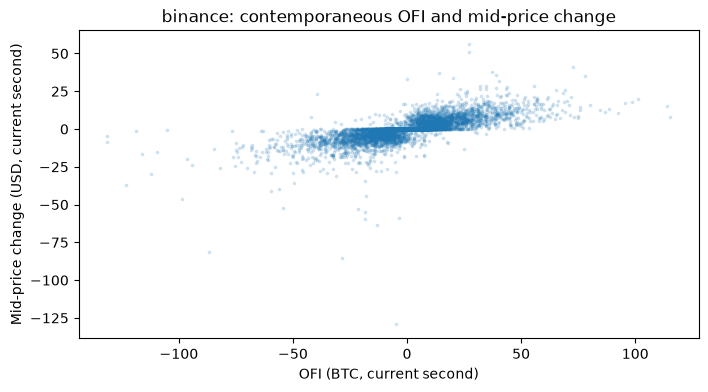

In [24]:
# Visual diagnostic: a deterministic sample of validation bars.
plot_data = validation_bars.drop_nulls("same_bar_change_usd").sample(
    n=min(10_000, validation_bars.drop_nulls("same_bar_change_usd").height), seed=7
)
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(plot_data["ofi"], plot_data["same_bar_change_usd"], s=3, alpha=0.15)
ax.set(xlabel="OFI (BTC, current second)", ylabel="Mid-price change (USD, current second)",
       title=f"{VENUE}: contemporaneous OFI and mid-price change")
plt.show()

## Interpretation and next decision

A positive contemporaneous slope is an impact relationship, not proof of forecasting power. Check the next-second validation score and the frequency of non-zero moves before treating OFI as a candidate signal. These are **single-venue** observations; a cross-venue lead/lag hypothesis would need separately aligned venue states and explicit latency assumptions. An order rule, inventory policy, fees and fill model require a separate design decision before any PnL claim. The held-out test split remains unused.